#RCEL 506 901 - Machine Learning Project

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [117]:
# Load dataset
train_df = pd.read_csv('train_FD001.txt', sep=r"\s+", header=None, names=columns)
test_df = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=columns)
columns = ["Unit", "Cycle", "Set1", "Set2", "Set3"] + [f"S{i}" for i in range(1, 22)]

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10142/3703513370.py:3: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=columns)


In [118]:
# Identify target variable
train_df['max_cycles'] = train_df.groupby('Unit')['Cycle'].transform('max')
# Calcuate RUL based on predicted max cycles
train_df['RUL'] = train_df['max_cycles'] - train_df['Cycle']

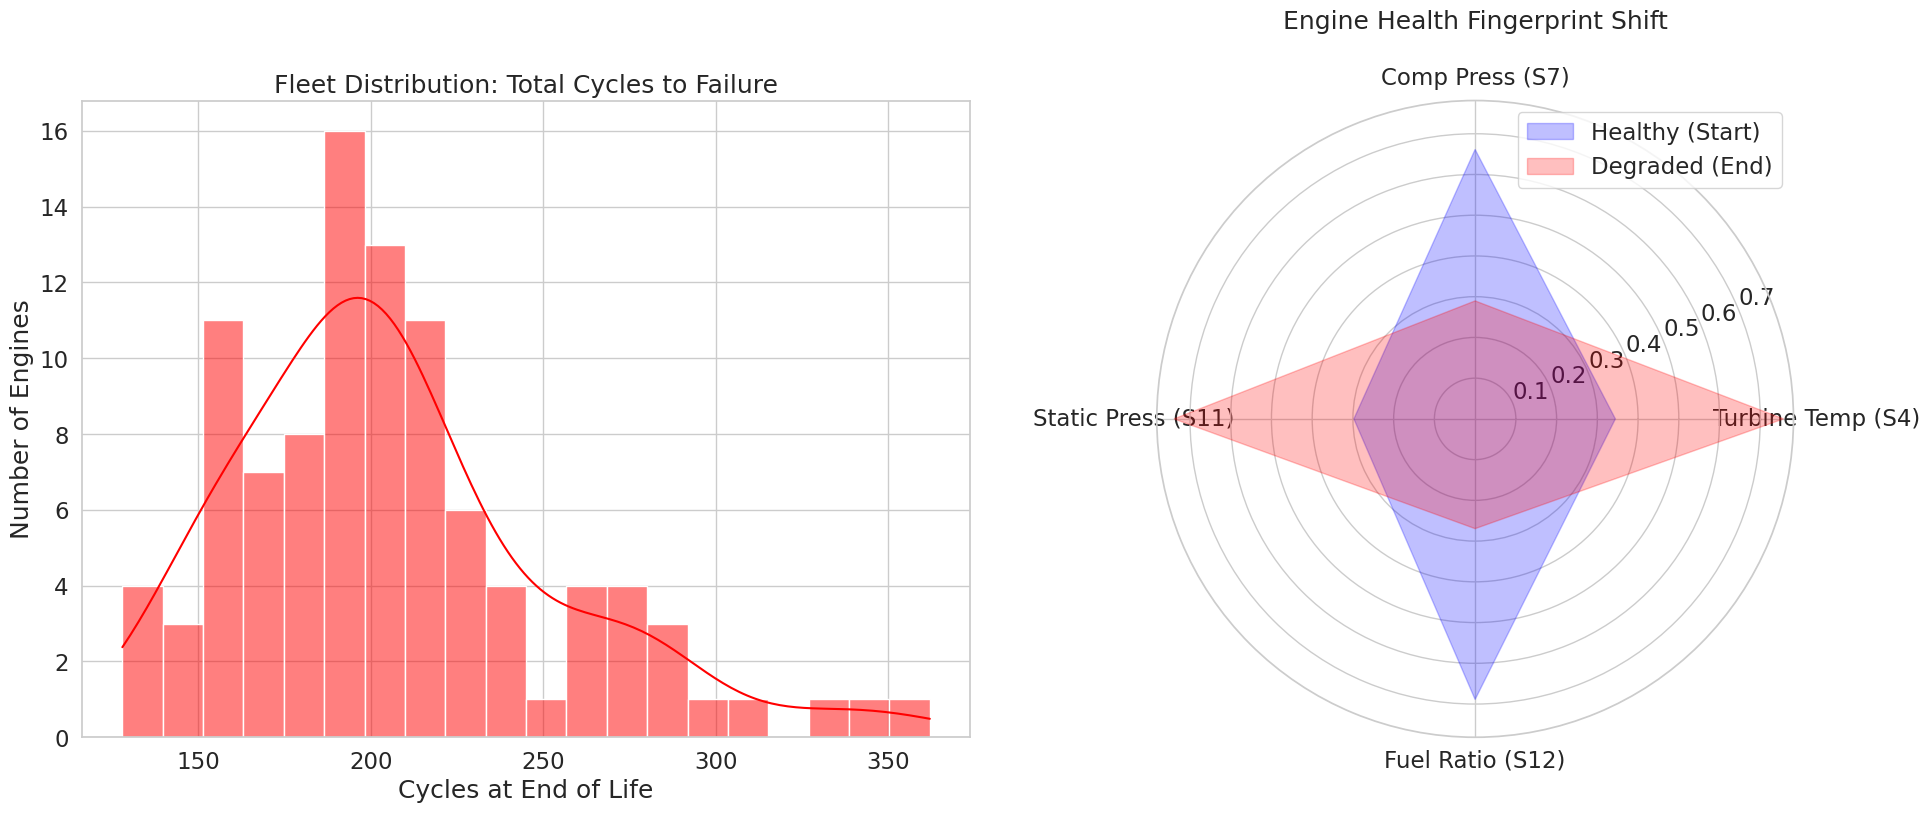

In [119]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(20, 15))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)

# Histogram to show the life span of the 100 engines in the dataset
plt.subplot(2, 2, 1) # First subplot for histogram
max_cycles = df.groupby('Unit')['Cycle'].max()
sns.histplot(max_cycles, bins=20, kde=True, color='red')
plt.title('Fleet Distribution: Total Cycles to Failure')
plt.xlabel('Cycles at End of Life')
plt.ylabel('Number of Engines')

key_sensors = ['S4', 'S7', 'S11', 'S12']
labels = ['Turbine Temp (S4)', 'Comp Press (S7)', 'Static Press (S11)', 'Fuel Ratio (S12)']

# Normalizing sensor data for plotting
df_norm = train_df.copy()
for s in key_sensors:
    df_norm[s] = (df_norm[s] - df_norm[s].min()) / (df_norm[s].max() - df_norm[s].min())

healthy = df_norm[df_norm['Cycle'] <= 10][key_sensors].mean().values
degraded = df_norm[df_norm['RUL'] <= 10][key_sensors].mean().values

# Generate Radar Chart
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
healthy_plot = np.concatenate((healthy, [healthy[0]])) # Close the radar chart shape
degraded_plot = np.concatenate((degraded, [degraded[0]])) # Close the radar chart shape
angles += angles[:1] # This line is correct to close the radar plot

# Use the same figure and a new subplot for the radar chart
ax = plt.subplot(2, 2, 2, polar=True) # Second subplot for radar chart, polar projection
ax.fill(angles, healthy_plot, color='blue', alpha=0.25, label='Healthy (Start)')
ax.fill(angles, degraded_plot, color='red', alpha=0.25, label='Degraded (End)')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Engine Health Fingerprint Shift", y=1.1)
plt.legend(loc='upper right')

plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.show()

In [120]:
# Establish naive baseline and determine benchmark scores
target_per_unit = train_df.groupby('Unit')['Cycle'].max()
baseline_val= target_per_unit.mean()
baseline_prediction = np.full(shape=target_per_unit.shape, fill_value=baseline_val)
baseline_rmse = np.sqrt(mean_squared_error(target_per_unit, baseline_prediction))

print(f"Baseline Mean Max Cycles: {baseline_val:.2f}")
print(f"Baseline RMSE Benchmark: {baseline_rmse:.2f}\n")

Baseline Mean Max Cycles: 206.31
Baseline RMSE Benchmark: 46.11



In [121]:
# Sensor standard deviation
sensor_cols = [f'S{i}' for i in range(1, 22)]

# Using < 1e-10 to identify sensors that are effectively constant but
# show tiny noise due to computer precision.
sensor_std = train_df[sensor_cols].std()

# Identify sensors with zero or near-zero variance
non_variant_sensors = sensor_std[sensor_std < 1e-10].index.tolist()

print("Standard Deviations:")
print(sensor_std)
print("\nNon-Variant Sensors to remove:", non_variant_sensors)

Standard Deviations:
S1     6.537152e-11
S2     5.000533e-01
S3     6.131150e+00
S4     9.000605e+00
S5     3.394700e-12
S6     1.388985e-03
S7     8.850923e-01
S8     7.098548e-02
S9     2.208288e+01
S10    4.660829e-13
S11    2.670874e-01
S12    7.375534e-01
S13    7.191892e-02
S14    1.907618e+01
S15    3.750504e-02
S16    1.556432e-14
S17    1.548763e+00
S18    0.000000e+00
S19    0.000000e+00
S20    1.807464e-01
S21    1.082509e-01
dtype: float64

Non-Variant Sensors to remove: ['S1', 'S5', 'S10', 'S16', 'S18', 'S19']


In [123]:
# Train the model
# Feature selection: Remove non-variant sensors to reduce technical crowding
drop_sensors = ['S1', 'S5', 'S10', 'S16', 'S18', 'S19']
features = [f for f in columns[2:] if f not in drop_sensors]

X_train = train_df[features]
y_train = train_df['max_cycles']

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [124]:
# Evaluate performance metrics
y_pred_train = model.predict(X_train)
model_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
model_mae = mean_absolute_error(y_train, y_pred_train)

print(f"Random Forest RMSE: {model_rmse:.2f}")
print(f"Improvement over Baseline: {((baseline_rmse - model_rmse) / baseline_rmse) * 100:.2f}%")
print(f"Mean Absolute Error (MAE): {model_mae:.2f} cycles")

Random Forest RMSE: 18.23
Improvement over Baseline: 60.47%
Mean Absolute Error (MAE): 14.24 cycles


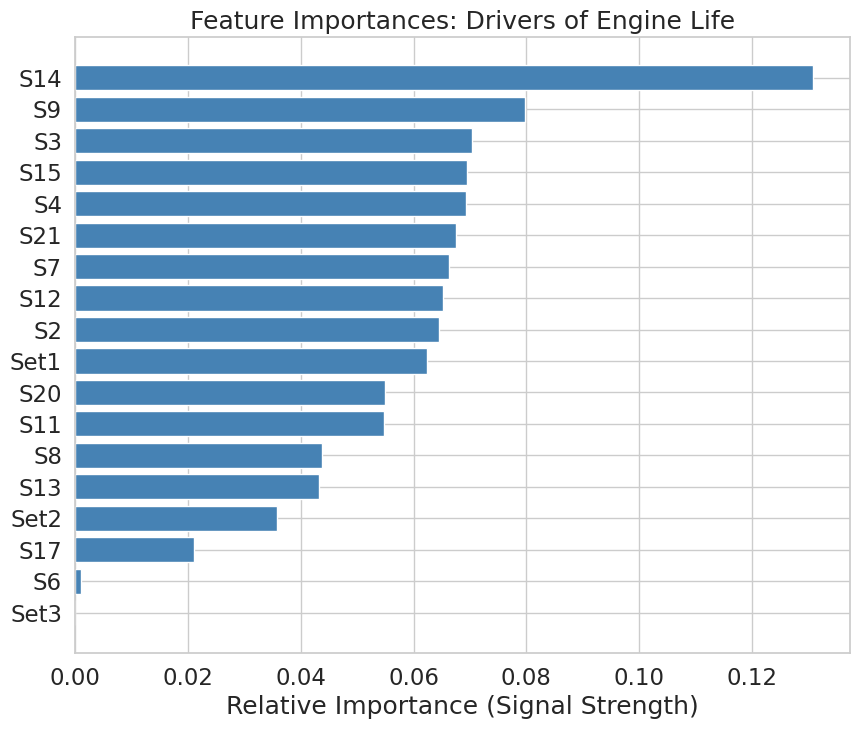

In [125]:
importances = model.feature_importances_
indices = np.argsort(importances)

# Feature Importance Bar Chart
plt.figure(figsize=(10, 8))
plt.title('Feature Importances: Drivers of Engine Life')
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance (Signal Strength)')
plt.show()

In [126]:
# Prep test data
test_last_cycle = test_df.groupby('Unit').last().reset_index()
X_test = test_last_cycle[features]

# Predict Total Max Cycles
predicted_max_cycles = model.predict(X_test)

# Calculate predicted RUL for the test set
predicted_rul = predicted_max_cycles - test_last_cycle['Cycle']

print(f"--- TEST SET PREDICTION SUMMARY ---")
print(f"Number of engines in test set: {len(predicted_max_cycles)}")
print(f"Average Predicted Total Life: {predicted_max_cycles.mean():.2f} cycles")
print(f"Average Predicted RUL: {predicted_rul.mean():.2f} cycles")
print(f"Min/Max Predicted RUL: {predicted_rul.min():.2f} / {predicted_rul.max():.2f}")

--- TEST SET PREDICTION SUMMARY ---
Number of engines in test set: 100
Average Predicted Total Life: 214.98 cycles
Average Predicted RUL: 84.02 cycles
Min/Max Predicted RUL: -76.92 / 202.18
